# 00 — Exploratory Data Analysis

Exploratory analysis of WHAS500 and UCI Heart Disease **before any modelling**:
missingness, class balance, distributions, outliers, and feature correlations.

This runs first in the pipeline (numbered `00`) — its job is to inform
modelling decisions (imputation strategy, scaling, which features might
need transforms), not to train anything.

## 1. Setup

In [1]:
import sys
sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.extract import load_both_datasets
from src.data.transform import clean_whas500, engineer_whas500_features
from src.utils.config import Paths, WHAS500Config, UCIHeartConfig

Paths.ensure_all()
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

whas_raw, uci_raw = load_both_datasets()
print('Setup OK')

2026-07-18 10:38:28 | INFO     | src.data.extract                    | WHAS500 loaded (bundled via scikit-survival): 500 patients, 16 columns, 43.0% died during follow-up


2026-07-18 10:38:28 | INFO     | src.data.extract                    | UCI Heart Disease already downloaded: uci_heart.csv


2026-07-18 10:38:28 | INFO     | src.data.extract                    | Loading UCI Heart Disease from C:\Users\Hp\Documents\patient_survival_prediction\data\raw\uci_heart.csv


2026-07-18 10:38:28 | INFO     | src.data.extract                    | UCI Heart Disease loaded: 303 patients, 13 features, 45.9% with heart disease


Setup OK


## 2. Data Dictionary

What each column actually means, before looking at any numbers — pulled from the same metadata the CLI (`predict info`) and SHAP plots use (`src/utils/constants.py`, `src/utils/config.py`), so this can't drift out of sync with the code.

In [2]:
from src.utils.constants import WHAS500_FEATURE_META

whas_target_meta = {
    WHAS500Config.time_col: {
        'display': 'Follow-up Time', 'role': 'survival time',
        'description': 'Days from hospital admission to death or last contact (censoring)',
        'unit': 'days', 'normal': None,
    },
    WHAS500Config.event_col: {
        'display': 'Vital Status', 'role': 'survival event',
        'description': 'Whether death was observed (1) or the patient was censored/alive at last contact (0)',
        'unit': 'binary', 'normal': None,
    },
    WHAS500Config.mortality_col: {
        'display': 'Mortality (derived)', 'role': 'ML target',
        'description': 'Binary mortality label used for classification — identical to fstat, named for clarity',
        'unit': 'binary', 'normal': None,
    },
}

rows = []
for col, meta in {**whas_target_meta, **{c: {**WHAS500_FEATURE_META[c],
        'role': 'numeric feature' if c in WHAS500Config.numeric_features else 'categorical feature'}
        for c in WHAS500_FEATURE_META}}.items():
    rows.append({
        'column': col,
        'role': meta.get('role', ''),
        'display': meta['display'],
        'description': meta['description'],
        'unit': meta.get('unit', ''),
        'normal_range': meta.get('normal') or '—',
    })

whas_dict = pd.DataFrame(rows).set_index('column')
print('WHAS500 — Data Dictionary')
whas_dict

WHAS500 — Data Dictionary


,role,display,description,unit,normal_range
column,,,,,
lenfol,survival time,Follow-up Time,Days from hospital admission to death or last ...,days,—
fstat,survival event,Vital Status,Whether death was observed (1) or the patient ...,binary,—
died,ML target,Mortality (derived),Binary mortality label used for classification...,binary,—
age,numeric feature,Age (years),Patient age at hospital admission,years,18–100
bmi,numeric feature,BMI (kg/m²),Body mass index at admission,kg/m²,18.5–24.9
sysbp,numeric feature,Systolic BP (mmHg),Initial systolic blood pressure,mmHg,90–120
diasbp,numeric feature,Diastolic BP (mmHg),Initial diastolic blood pressure,mmHg,60–80
hr,numeric feature,Heart Rate (bpm),Initial heart rate at admission,bpm,60–100
los,numeric feature,Length of Stay (days),Duration of the index hospitalisation,days,1–14


In [3]:
from src.utils.constants import UCI_FEATURE_META

uci_target_meta = {
    UCIHeartConfig.target_col: {
        'display': 'Heart Disease Presence', 'role': 'ML target',
        'description': 'Binarised outcome: 0 = no disease, 1 = disease present (collapsed from the original 0–4 severity scale)',
        'unit': 'binary', 'normal': None,
    },
}

rows = []
for col, meta in {**uci_target_meta, **{c: {**UCI_FEATURE_META[c],
        'role': 'numeric feature' if c in UCIHeartConfig.numeric_features else 'categorical feature'}
        for c in UCI_FEATURE_META}}.items():
    rows.append({
        'column': col,
        'role': meta.get('role', ''),
        'display': meta['display'],
        'description': meta['description'],
        'unit': meta.get('unit', ''),
        'normal_range': meta.get('normal') or '—',
    })

uci_dict = pd.DataFrame(rows).set_index('column')
print('UCI Heart Disease — Data Dictionary')
uci_dict

UCI Heart Disease — Data Dictionary


,role,display,description,unit,normal_range
column,,,,,
target,ML target,Heart Disease Presence,"Binarised outcome: 0 = no disease, 1 = disease...",binary,—
age,numeric feature,Age (years),Patient age,years,18–100
sex,categorical feature,Sex,"1=Male, 0=Female",binary,—
cp,categorical feature,Chest Pain Type,"1=Typical angina, 2=Atypical, 3=Non-anginal, 4...",categorical,—
trestbps,numeric feature,Resting BP (mmHg),Resting blood pressure at admission,mmHg,90–120
chol,numeric feature,Cholesterol (mg/dL),Serum cholesterol,mg/dL,<200
fbs,categorical feature,Fasting Blood Sugar >120,Fasting blood sugar > 120 mg/dL (1=True),binary,—
restecg,categorical feature,Resting ECG,"0=Normal, 1=ST-T abnormality, 2=LV hypertrophy",categorical,—
thalach,numeric feature,Max Heart Rate,Maximum heart rate achieved,bpm,60–202


## 3. WHAS500 — Overview

500 acute MI patients, real time-to-event mortality data.

In [4]:
print(f'Shape: {whas_raw.shape}')
whas_raw.info()

Shape: (500, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   afb     500 non-null    int64  
 1   age     500 non-null    float64
 2   av3     500 non-null    int64  
 3   bmi     500 non-null    float64
 4   chf     500 non-null    int64  
 5   cvd     500 non-null    int64  
 6   diasbp  500 non-null    float64
 7   sex     500 non-null    int64  
 8   hr      500 non-null    float64
 9   los     500 non-null    float64
 10  miord   500 non-null    int64  
 11  mitype  500 non-null    int64  
 12  sho     500 non-null    int64  
 13  sysbp   500 non-null    float64
 14  lenfol  500 non-null    float64
 15  fstat   500 non-null    int64  
dtypes: float64(7), int64(9)
memory usage: 62.6 KB


In [5]:
whas_raw.head()

,afb,age,av3,bmi,chf,cvd,diasbp,sex,hr,los,miord,mitype,sho,sysbp,lenfol,fstat
0,1,83.0,0,25.54051,0,1,78.0,0,89.0,5.0,1,0,0,152.0,2178.0,0
1,0,49.0,0,24.02398,0,1,60.0,0,84.0,5.0,0,1,0,120.0,2172.0,0
2,0,70.0,0,22.14290,0,0,88.0,1,83.0,5.0,0,1,0,147.0,2190.0,0
3,0,70.0,0,26.63187,1,1,76.0,0,65.0,10.0,0,1,0,123.0,297.0,1
4,0,70.0,0,24.41255,0,1,85.0,0,63.0,6.0,0,1,0,135.0,2131.0,0


## 4. WHAS500 — Missing Values

In [6]:
missing = whas_raw.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing):
    print(missing)
else:
    print('No missing values in the raw WHAS500 data.')

No missing values in the raw WHAS500 data.


## 5. WHAS500 — Target Balance (Mortality) & Follow-up Time

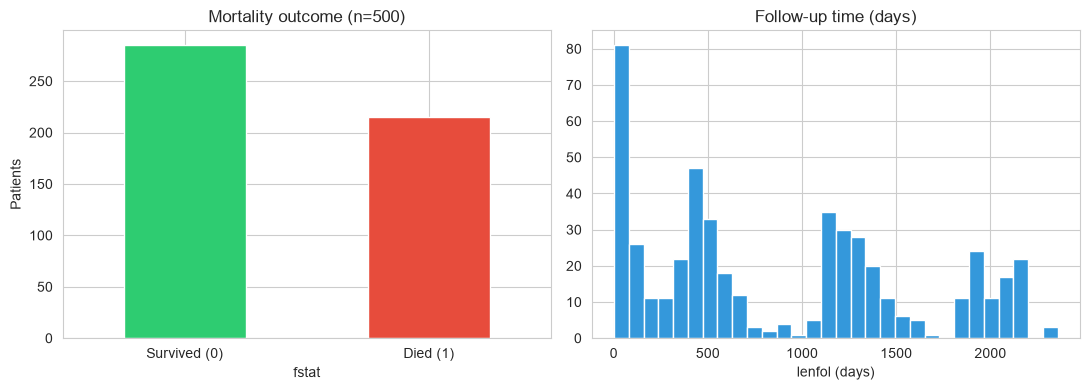

Mortality rate: 43.0%
Median follow-up: 632 days


In [7]:
cfg = WHAS500Config
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

whas_raw[cfg.event_col].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c']
)
axes[0].set_xticklabels(['Survived (0)', 'Died (1)'], rotation=0)
axes[0].set_title(f'Mortality outcome (n={len(whas_raw)})')
axes[0].set_ylabel('Patients')

axes[1].hist(whas_raw[cfg.time_col], bins=30, color='#3498db', edgecolor='white')
axes[1].set_title('Follow-up time (days)')
axes[1].set_xlabel('lenfol (days)')
plt.tight_layout()
plt.show()

print(f"Mortality rate: {whas_raw[cfg.event_col].mean():.1%}")
print(f"Median follow-up: {whas_raw[cfg.time_col].median():.0f} days")

## 6. WHAS500 — Numeric Feature Distributions

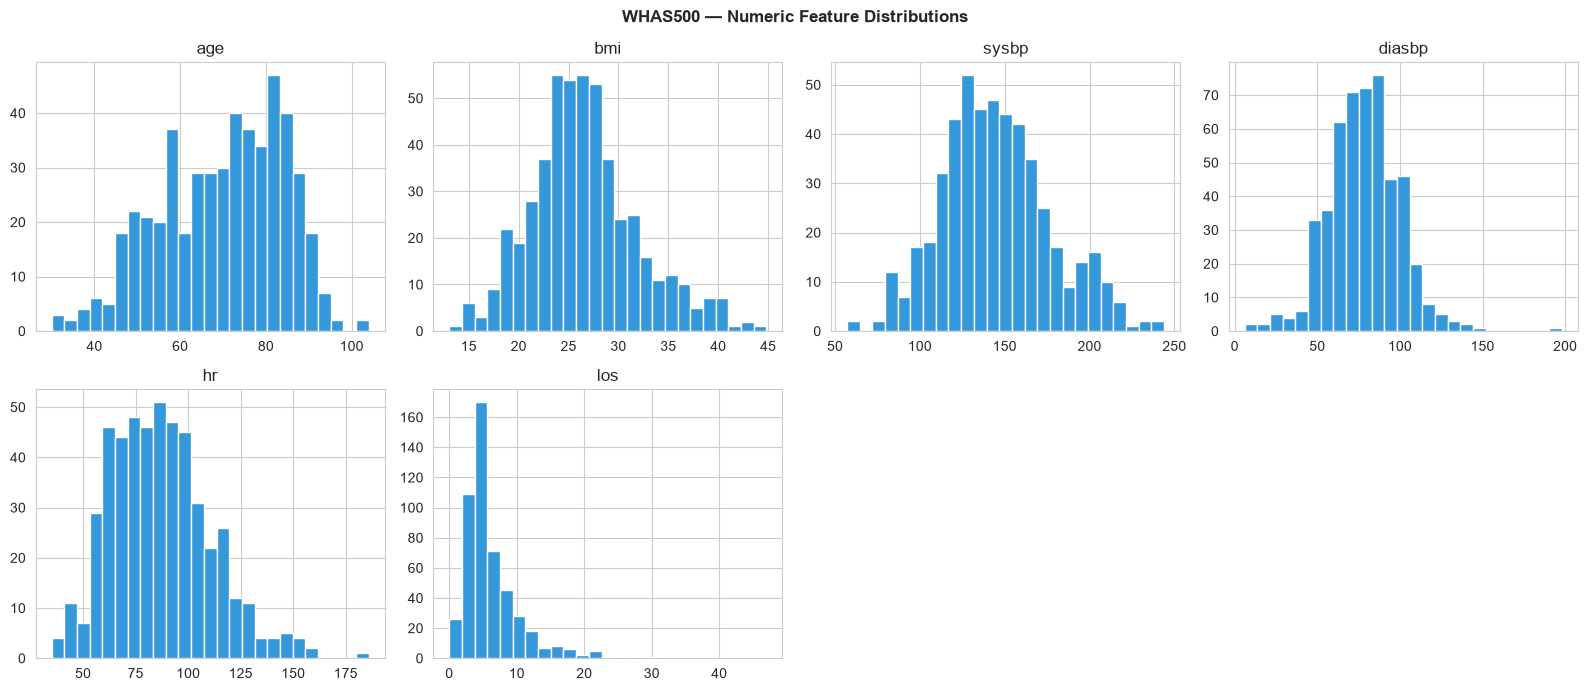

In [8]:
numeric_cols = cfg.numeric_features
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(whas_raw[col].dropna(), bins=25, color='#3498db', edgecolor='white')
    axes[i].set_title(col)

for ax in axes[len(numeric_cols):]:
    ax.axis('off')

plt.suptitle('WHAS500 — Numeric Feature Distributions', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. WHAS500 — Outlier Check

Boxplots on the raw (unscaled) numeric features to flag clinically
implausible values before they hit the imputation/scaling step.

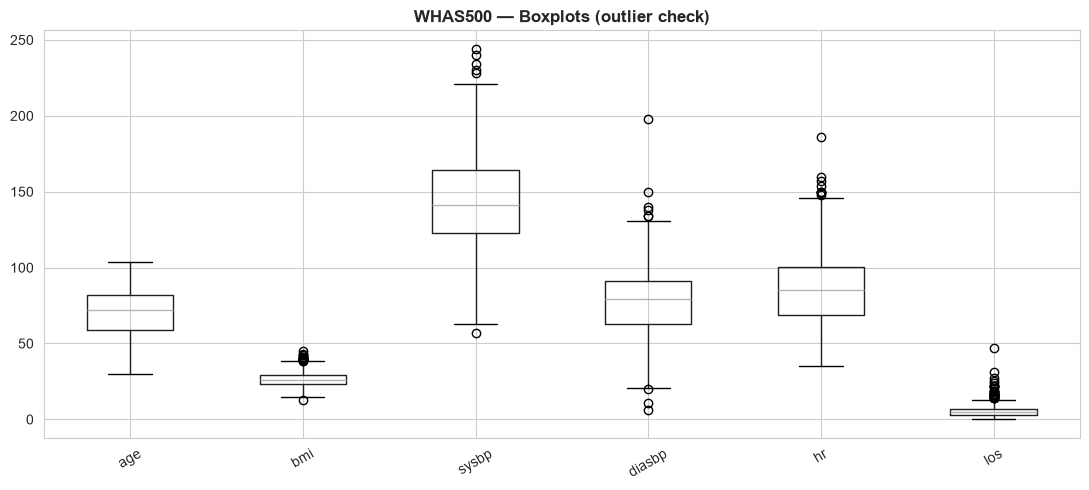

,min,25%,50%,75%,max
age,30.0,59.0,72.0,82.0,104.0
bmi,13.0,23.2,25.9,29.4,44.8
sysbp,57.0,123.0,141.5,164.0,244.0
diasbp,6.0,63.0,79.0,91.2,198.0
hr,35.0,69.0,85.0,100.2,186.0
los,0.0,3.0,5.0,7.0,47.0


In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
whas_raw[numeric_cols].boxplot(ax=ax)
ax.set_title('WHAS500 — Boxplots (outlier check)', fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

whas_raw[numeric_cols].describe().T[['min', '25%', '50%', '75%', 'max']].round(1)

## 8. WHAS500 — Categorical Feature Counts

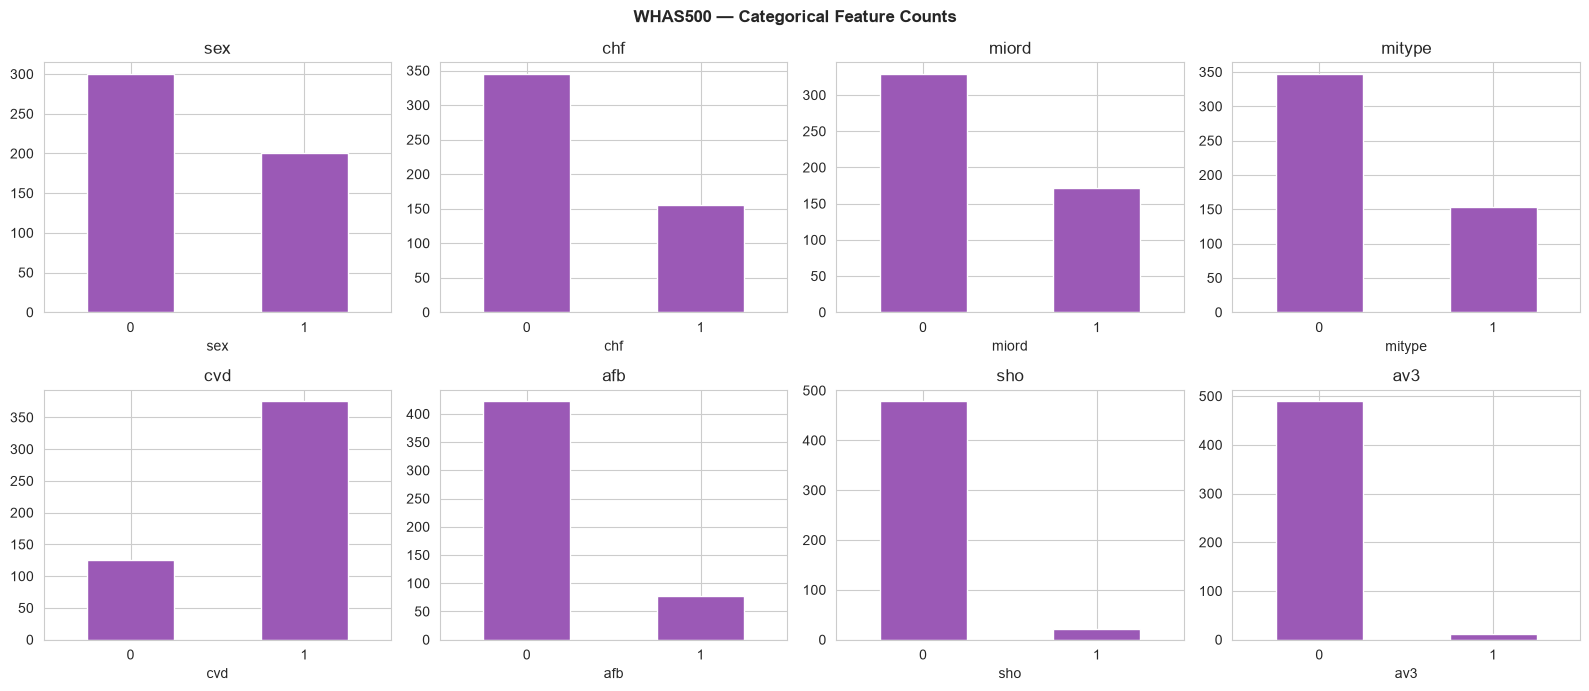

In [10]:
cat_cols = cfg.categorical_features
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    whas_raw[col].value_counts().sort_index().plot(kind='bar', ax=axes[i], color='#9b59b6')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('WHAS500 — Categorical Feature Counts', fontweight='bold')
plt.tight_layout()
plt.show()

## 9. WHAS500 — Feature Correlation

Relevant for the Cox PH model in particular, which assumes limited
multicollinearity among covariates.

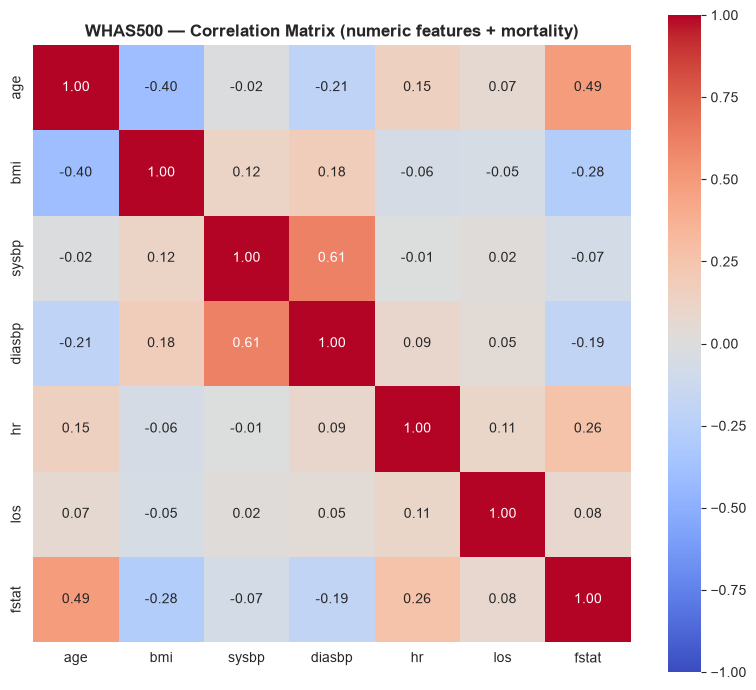

Correlation with mortality (fstat), sorted:
age       0.486135
hr        0.259253
los       0.078970
sysbp    -0.074674
diasbp   -0.188289
bmi      -0.277481
Name: fstat, dtype: float64


In [11]:
corr_cols = numeric_cols + [cfg.event_col]
corr = whas_raw[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('WHAS500 — Correlation Matrix (numeric features + mortality)', fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlation with mortality (fstat), sorted:')
print(corr[cfg.event_col].drop(cfg.event_col).sort_values(ascending=False))

## 10. WHAS500 — Mortality by Age Group & Sex

2026-07-18 10:38:33 | INFO     | src.data.transform                  | WHAS500 cleaned: 500 patients, 43.0% mortality


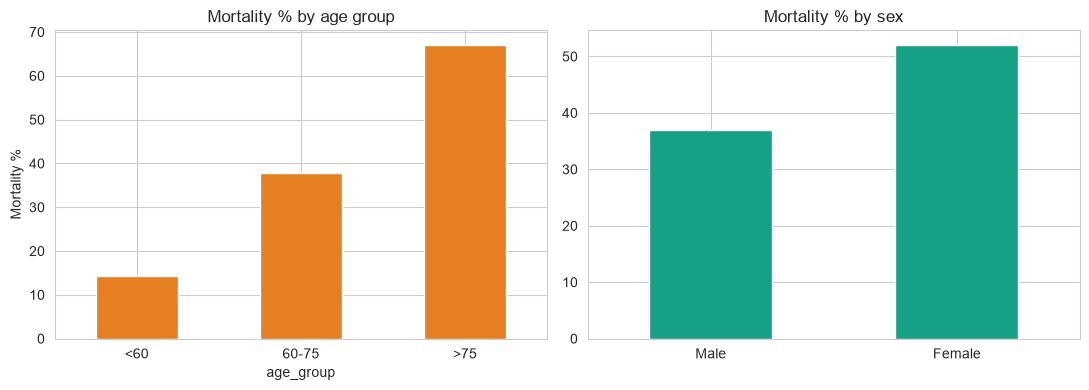

In [12]:
whas_clean = clean_whas500(whas_raw)
whas_eng   = engineer_whas500_features(whas_clean)

mort_by_age = whas_eng.groupby('age_group', observed=True)[cfg.mortality_col].mean() * 100
mort_by_sex = whas_eng.groupby('sex', observed=True)[cfg.mortality_col].mean() * 100
mort_by_sex.index = ['Male', 'Female']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
mort_by_age.plot(kind='bar', ax=axes[0], color='#e67e22')
axes[0].set_title('Mortality % by age group')
axes[0].set_ylabel('Mortality %')
axes[0].tick_params(axis='x', rotation=0)

mort_by_sex.plot(kind='bar', ax=axes[1], color='#16a085')
axes[1].set_title('Mortality % by sex')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 11. UCI Heart Disease — Overview

303 patients, binary heart-disease target — used as a secondary
benchmark dataset, not combined with WHAS500.

In [13]:
ucfg = UCIHeartConfig
print(f'Shape: {uci_raw.shape}')
uci_raw.info()

Shape: (303, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


## 12. UCI Heart Disease — Missing Values & Target Balance

ca      4
thal    2
dtype: int64


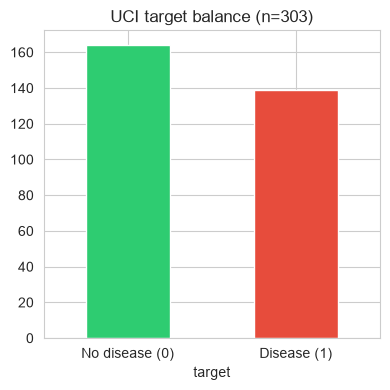

Disease prevalence: 45.9%


In [14]:
missing_uci = uci_raw.isna().sum()
missing_uci = missing_uci[missing_uci > 0].sort_values(ascending=False)
print(missing_uci if len(missing_uci) else 'No missing values in raw UCI data.')

fig, ax = plt.subplots(figsize=(4, 4))
uci_raw[ucfg.target_col].value_counts().sort_index().plot(
    kind='bar', ax=ax, color=['#2ecc71', '#e74c3c']
)
ax.set_xticklabels(['No disease (0)', 'Disease (1)'], rotation=0)
ax.set_title(f'UCI target balance (n={len(uci_raw)})')
plt.tight_layout()
plt.show()

print(f"Disease prevalence: {uci_raw[ucfg.target_col].mean():.1%}")

## 13. UCI Heart Disease — Numeric Distributions & Correlation

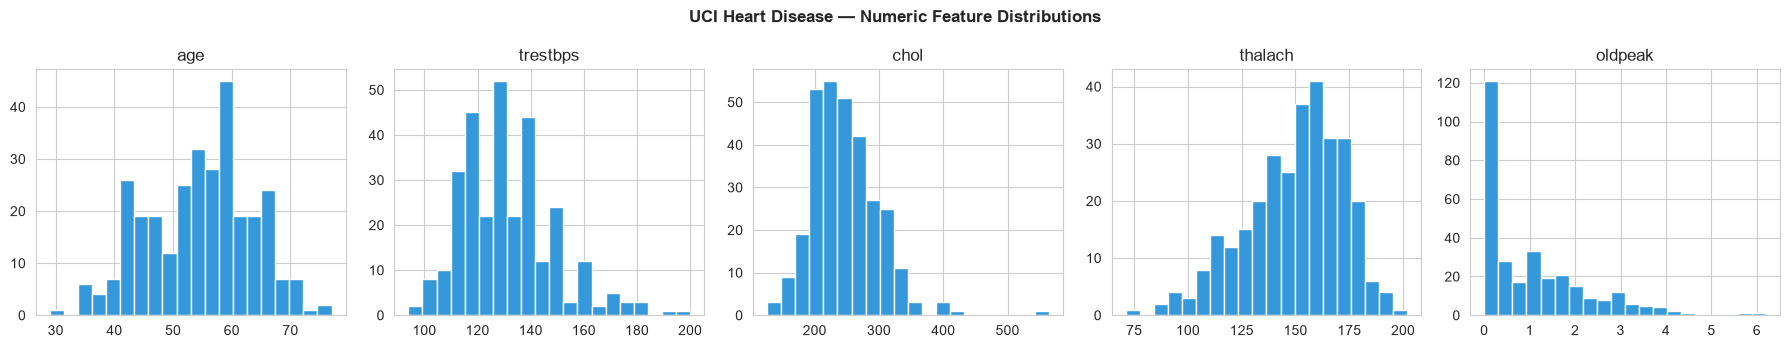

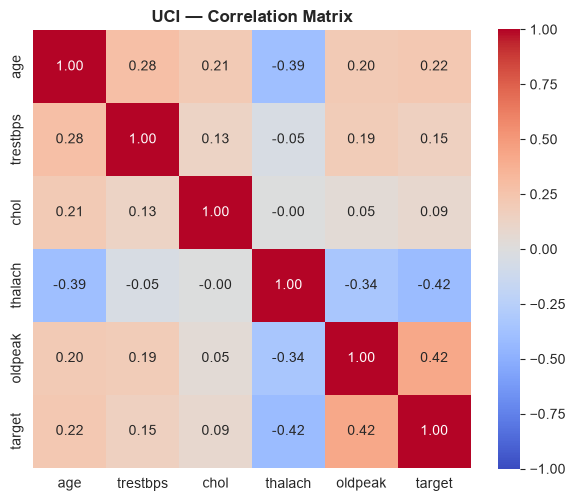

In [15]:
uci_numeric = ucfg.numeric_features
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
for i, col in enumerate(uci_numeric):
    axes[i].hist(uci_raw[col].dropna(), bins=20, color='#3498db', edgecolor='white')
    axes[i].set_title(col)
plt.suptitle('UCI Heart Disease — Numeric Feature Distributions', fontweight='bold')
plt.tight_layout()
plt.show()

corr_uci = uci_raw[uci_numeric + [ucfg.target_col]].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_uci, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('UCI — Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

## 14. Key Takeaways

**WHAS500** (500 acute MI patients, no missing values in the raw data):
- Mortality rate 43.0%, median follow-up 632 days — moderate class imbalance,
  consistent with the class-weighting already used in `src/models/train.py`.
- **Age** is by far the strongest univariate correlate of mortality (r = 0.49),
  followed by heart rate (r = 0.26). BMI (r = -0.28) and diastolic BP
  (r = -0.19) show mild *negative* correlation with mortality in this raw,
  unadjusted view — plausible given this is a sick population (very low BMI/BP
  at admission can itself signal severity), but it means these two shouldn't
  be read as "protective" without controlling for confounders in the Cox
  model and ML feature importances.
- No extreme outliers stood out in the boxplots beyond what's clinically
  plausible for an acute MI cohort.

**UCI Heart Disease** (303 patients):
- Only two columns have missing values: `ca` (4 rows) and `thal` (2 rows) —
  small enough that the existing median/mode imputation in
  `clean_uci_heart()` is a reasonable choice, not a compromise.
- Disease prevalence 45.9% — close to WHAS500's mortality rate, so the same
  class-imbalance handling approach carries over reasonably well.

**Modelling implications**:
- Standardising numeric features (already done in `scale_features()`) is
  worthwhile given the differing scales of age/bmi/sysbp/hr/los.
- The Cox PH model's proportional-hazards assumption should be checked
  (it already is, via `cox.zph()` in `r/survival.R`) given the correlation
  structure observed here between age, BP, and BMI.